ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook


In [42]:
import pandas as pd
import numpy as np
import re
# Load dataset
df = pd.read_csv('googleplaystore.csv')

# 1. Display first 5 rows of raw data
print("Raw data samples (Before Cleaning):")
display(df.head())

# 2. Display last 5 rows of raw data
display(df.tail())

# 3. Show specific columns with symbols
print("\nRaw strings in specific columns:")
print(df[['App', 'Installs', 'Price', 'Size']].head(10))

# Check data types and structure
df.info()

# Find any ratings above 5.0
bad_rows = df[df['Rating'] > 5]
print("Corrupted rows found:", bad_rows)

# Check for symbols in numeric columns
print("Installs sample:", df['Installs'].unique()[:3])
print("Price sample:", df['Price'].unique()[:3])

Raw data samples (Before Cleaning):


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device



Raw strings in specific columns:
                                                 App     Installs Price  Size
0     Photo Editor & Candy Camera & Grid & ScrapBook      10,000+     0   19M
1                                Coloring book moana     500,000+     0   14M
2  U Launcher Lite – FREE Live Cool Themes, Hide ...   5,000,000+     0  8.7M
3                              Sketch - Draw & Paint  50,000,000+     0   25M
4              Pixel Draw - Number Art Coloring Book     100,000+     0  2.8M
5                         Paper flowers instructions      50,000+     0  5.6M
6            Smoke Effect Photo Maker - Smoke Editor      50,000+     0   19M
7                                   Infinite Painter   1,000,000+     0   29M
8                               Garden Coloring Book   1,000,000+     0   33M
9                      Kids Paint Free - Drawing Fun      10,000+     0  3.1M
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):

**Missing Values & Duplicates**

In [44]:
# 1. Check for missing values (NaNs) in each column
print("Missing values per column:")
print(df.isnull().sum())

# 2. Check for exact duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nTotal exact duplicate rows found: {duplicate_count}")

# 3. Check for duplicate App names
# (This finds apps listed multiple times with different stats)
name_duplicates = df['App'].duplicated().sum()
print(f"Duplicate App names found: {name_duplicates}")


Missing values per column:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Total exact duplicate rows found: 483
Duplicate App names found: 1181


In [45]:
# 1. Remove corrupted shifted row
df = df.drop(df[df['Rating'] > 5].index)

# 2. Clean 'Installs'
df['Installs'] = df['Installs'].astype(str).str.replace('+', '').str.replace(',', '').astype(int)

# 3. Clean 'Price' (Remove '$' symbol)
df['Price'] = df['Price'].astype(str).str.replace('$', '').astype(float)

# 4. Standardize 'Size'
def clean_size(val):
    val = str(val).upper()
    if 'VARIES WITH DEVICE' in val or 'NAN' in val:
        return np.nan

    # Extract only the numeric part
    number = re.findall(r"[-+]?\d*\.\d+|\d+", val)
    if not number:
        return np.nan

    number = float(number[0])

    # Convert based on suffix
    if 'M' in val:
        return number
    if 'K' in val:
        return number / 1024
    return number

df['Size'] = df['Size'].apply(clean_size)

# 5. Convert 'Reviews' to integer
df['Reviews'] = df['Reviews'].astype(int)

# 6. Transform 'Last Updated' to Time Series (DateTime)
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

# 7. Drop version columns (Inconsistent data)
df = df.drop(columns=['Android Ver', 'Current Ver'])

# 8. Deduplicate Apps (Keep entry with most reviews)
df = df.sort_values('Reviews', ascending=False)
df = df.drop_duplicates(subset=['App'])

# 9. Drop rows with missing Ratings
df = df.dropna(subset=['Rating'])

In [23]:
# Show final shape and data types
print("Cleaned Dataset Shape:", df.shape)
df.info()

# Show summary stats
display(df.describe())


print("\nFinal Numeric Summary:")
display(df.describe())

# Preview the clean data
print("\nCleaned Data Preview:")
display(df.head(25))

Cleaned Dataset Shape: (8196, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 8196 entries, 2544 to 8497
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             8196 non-null   object        
 1   Category        8196 non-null   object        
 2   Rating          8196 non-null   float64       
 3   Reviews         8196 non-null   int64         
 4   Size            7026 non-null   float64       
 5   Installs        8196 non-null   int64         
 6   Type            8196 non-null   object        
 7   Price           8196 non-null   float64       
 8   Content Rating  8196 non-null   object        
 9   Genres          8196 non-null   object        
 10  Last Updated    8196 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 768.4+ KB


,Rating,Reviews,Size,Installs,Price,Last Updated
count,8196.000000,8.196000e+03,7026.000000,8.196000e+03,8196.000000,8196
mean,4.173267,2.555008e+05,21.758067,9.189442e+06,1.035447,2017-11-05 10:31:26.969253120
min,1.000000,1.000000e+00,0.008301,1.000000e+00,0.000000,2010-05-21 00:00:00
25%,4.000000,1.270000e+02,4.900000,1.000000e+04,0.000000,2017-08-17 00:00:00
50%,4.300000,3.017000e+03,13.000000,1.000000e+05,0.000000,2018-05-20 00:00:00
75%,4.500000,4.397675e+04,31.000000,1.000000e+06,0.000000,2018-07-19 00:00:00
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000,2018-08-08 00:00:00
std,0.536253,1.985709e+06,22.727958,5.826274e+07,16.857244,NaN



Final Numeric Summary:


,Rating,Reviews,Size,Installs,Price,Last Updated
count,8196.000000,8.196000e+03,7026.000000,8.196000e+03,8196.000000,8196
mean,4.173267,2.555008e+05,21.758067,9.189442e+06,1.035447,2017-11-05 10:31:26.969253120
min,1.000000,1.000000e+00,0.008301,1.000000e+00,0.000000,2010-05-21 00:00:00
25%,4.000000,1.270000e+02,4.900000,1.000000e+04,0.000000,2017-08-17 00:00:00
50%,4.300000,3.017000e+03,13.000000,1.000000e+05,0.000000,2018-05-20 00:00:00
75%,4.500000,4.397675e+04,31.000000,1.000000e+06,0.000000,2018-07-19 00:00:00
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000,2018-08-08 00:00:00
std,0.536253,1.985709e+06,22.727958,5.826274e+07,16.857244,NaN



Cleaned Data Preview:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated
2544,Facebook,SOCIAL,4.1,78158306,NaN,1000000000,Free,0.0,Teen,Social,2018-08-03
381,WhatsApp Messenger,COMMUNICATION,4.4,69119316,NaN,1000000000,Free,0.0,Everyone,Communication,2018-08-03
2604,Instagram,SOCIAL,4.5,66577446,NaN,1000000000,Free,0.0,Teen,Social,2018-07-31
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,NaN,1000000000,Free,0.0,Everyone,Communication,2018-08-01
1879,Clash of Clans,GAME,4.6,44893888,98.0,100000000,Free,0.0,Everyone 10+,Strategy,2018-07-15
4005,Clean Master- Space Cleaner & Antivirus,TOOLS,4.7,42916526,NaN,500000000,Free,0.0,Everyone,Tools,2018-08-03
1917,Subway Surfers,GAME,4.5,27725352,76.0,1000000000,Free,0.0,Everyone 10+,Arcade,2018-07-12
3665,YouTube,VIDEO_PLAYERS,4.3,25655305,NaN,1000000000,Free,0.0,Teen,Video Players & Editors,2018-08-02
7536,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,4.7,24900999,NaN,500000000,Free,0.0,Everyone,Tools,2018-08-04
1878,Clash Royale,GAME,4.6,23136735,97.0,100000000,Free,0.0,Everyone 10+,Strategy,2018-06-27


In [46]:
df.to_csv('googleplaystore_cleaned.csv', index=False)
from google.colab import files
files.download('googleplaystore_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Data Cleaning Steps:**

Why Cleaning was Needed?
The raw dataset contained significant "noise" including:

1.	Corrupted Rows: A shifted row with a rating of 19.0.

2.	Incorrect Formats: 'Installs' and 'Price' were stored as strings with symbols (+, ,, $).

3.	Inconsistent Units: 'Size' used mixed characters ('M' for MB and 'k' for KB).

4.	Duplicates: Multiple entries for the same app with different review counts.

5.	Missing Values: Over 1,400 missing Ratings and several missing version strings.

Changes Made:

• Numeric Conversion: Stripped all symbols from Installs and Price to enable mathematical analysis.

• Unit Standardization: Created a function to convert all Size entries to a uniform Megabyte (MB) scale.

• Time-Series Transformation: Converted Last Updated to a datetime object to track trends over time.

• Deduplication: Sorted by Reviews and kept only the most popular entry for each unique App name.

• Feature Selection: Dropped Android Ver and Current Ver columns due to extreme inconsistency.

**1. Distribution of App Ratings**

• Explanation: This histogram shows that the majority of apps have a high rating, typically between 4.0 and 4.7.

• Insight: The data is "left-skewed," suggesting that users are generally generous with ratings, or that low-quality apps are removed or ignored. It proves that a rating below 4.0 is actually considered "below average" in this marketplace.



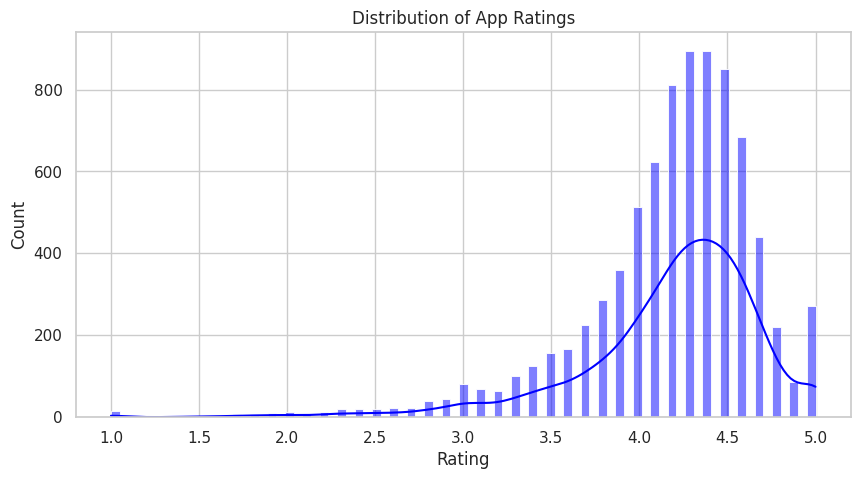

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set visual style
sns.set(style="whitegrid")

# 1. App Ratings Distribution
# Shows frequency of scores.
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], kde=True, color='blue')
plt.title('Distribution of App Ratings')
plt.show()


**2. Number of Apps per Category**

• Explanation: This bar chart ranks categories by the quantity of apps available.

• Insight: Categories like Family, Game, and Tools usually dominate. This highlights which sectors are the most competitive for developers and where the most variety exists for users.

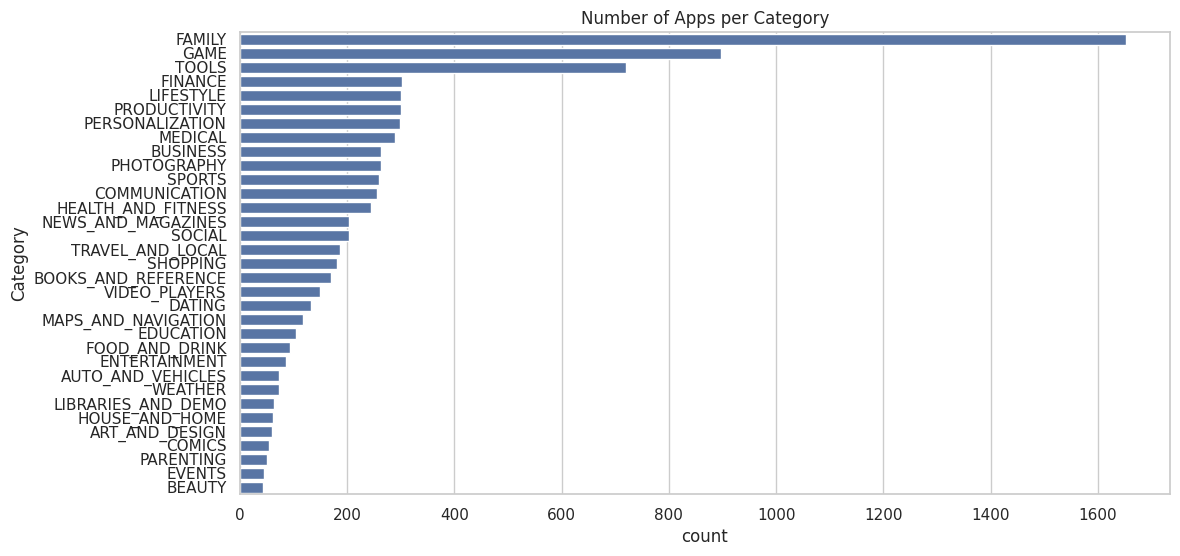

In [32]:
# 2. Apps per Category
# Shows the most crowded categories.
plt.figure(figsize=(12, 6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index)
plt.title('Number of Apps per Category')
plt.show()

**3. Free vs. Paid Apps**

• Explanation: This pie chart visualizes the ratio of free apps to those that require a purchase.

• Insight: Overwhelmingly, the store is dominated by Free apps 92.7%. This confirms that the "Freemium" model (free to download with ads or in-app purchases) is the standard business strategy on Android.

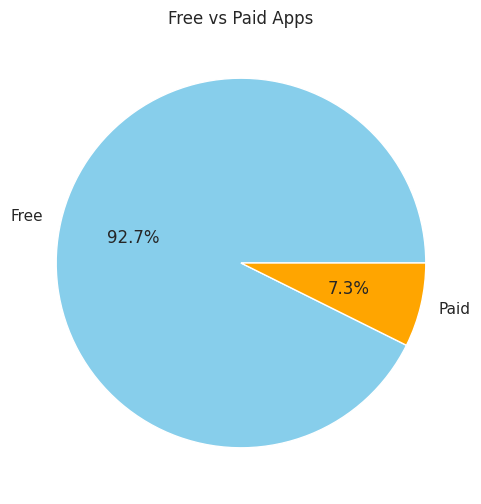

In [33]:

# 3. Free vs Paid Apps
# Comparison of market share.
plt.figure(figsize=(6, 6))
df['Type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'orange'])
plt.title('Free vs Paid Apps')
plt.ylabel('')
plt.show()

**4. Top 10 Categories by Average Installs**

• Explanation: This chart identifies which categories get the most "reach" or downloads per app.

• Insight: While "Family" might have the most apps, categories like Communication or Social often have the highest average installs. This shows where the mass-market audience spends their time.

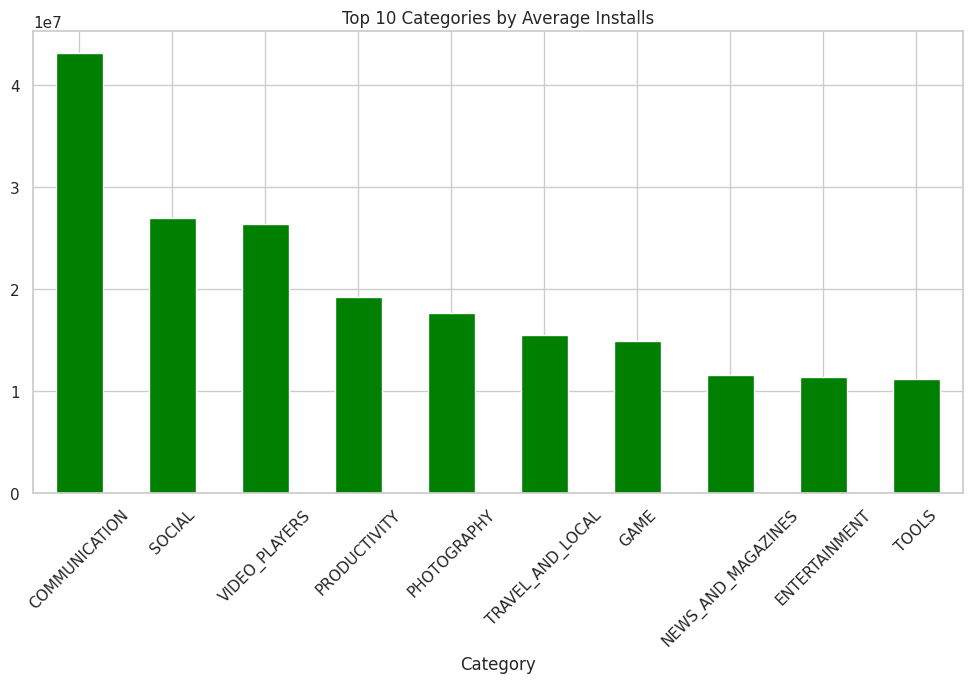

In [34]:
# 4. Top 10 Categories by Installs
# Shows which categories are most downloaded.
top_installs = df.groupby('Category')['Installs'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
top_installs.plot(kind='bar', color='green')
plt.title('Top 10 Categories by Average Installs')
plt.xticks(rotation=45)
plt.show()

**5. Rating vs. Content Rating**

• Explanation: This boxplot compares user satisfaction across different age groups (Everyone, Teen, Mature 17+, etc.).

• Insight: It helps identify if certain audiences are more critical. For example, "Mature" or "Everyone 10+" apps might show higher variance in ratings compared to "Everyone" rated apps.

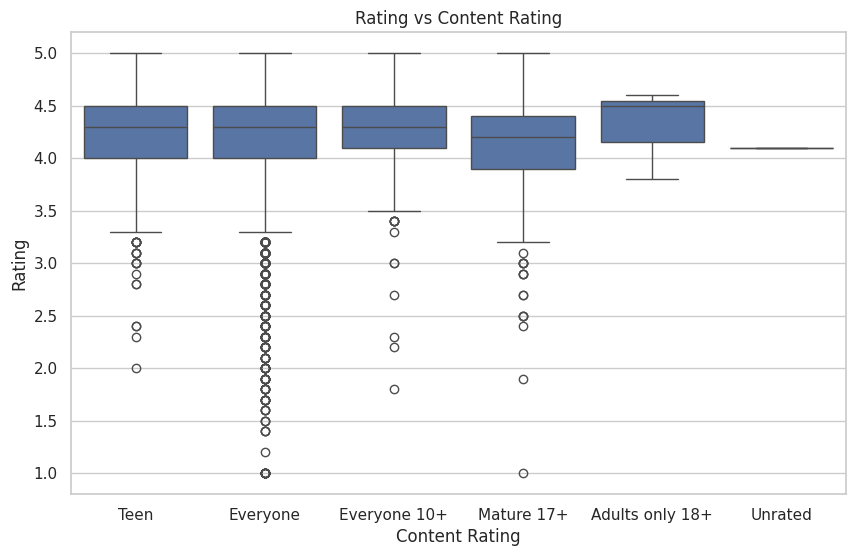

In [35]:
# 5. Rating vs Content Rating
# User satisfaction across age groups.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Content Rating', y='Rating', data=df)
plt.title('Rating vs Content Rating')
plt.show()

**6. App Size (MB) vs. Rating**

• Explanation: This scatter plot shows the relationship between the file size and the user rating.

• Insight: It reveals if "heavy" apps (large MB) are perceived as higher quality or if users prefer "lightweight" apps. Usually, there is no strict linear correlation, meaning a big app isn't guaranteed a better rating.

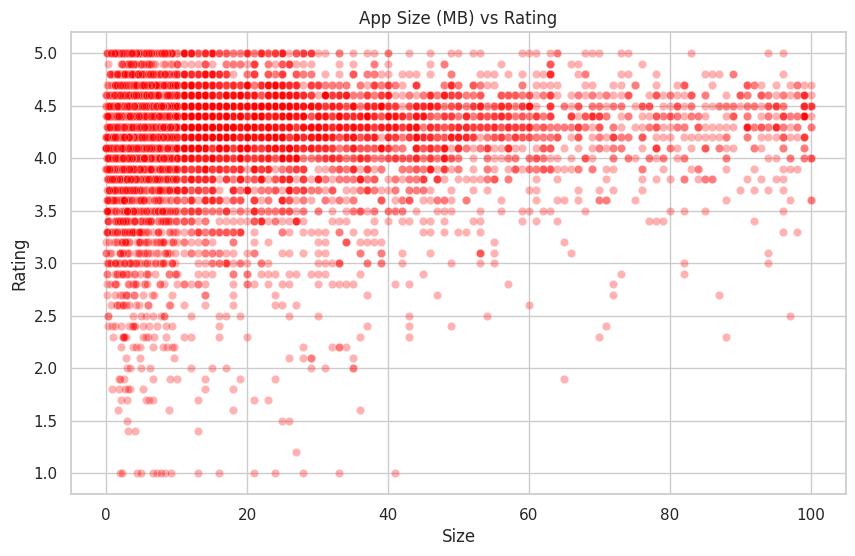

In [36]:
# 6. Size vs Rating
# Checks if larger apps have different ratings.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Rating', data=df, alpha=0.3, color='red')
plt.title('App Size (MB) vs Rating')
plt.show()

**7. Distribution of Content Rating**

• Description: This visualization uses a count plot to categorize apps based on their intended audience age group, such as Everyone, Teen, Mature 17+, and Everyone 10+.

• Analysis: The graph shows an overwhelming dominance of the "Everyone" category. This indicates that the vast majority of developers on the platform aim for the broadest possible market reach.

• Insight: By keeping content accessible to all ages, developers minimize barriers to entry. This distribution confirms that the Play Store ecosystem is primarily built around family-friendly content, with specialized niches for mature or teenage-specific audiences representing only a small fraction of the total app count.

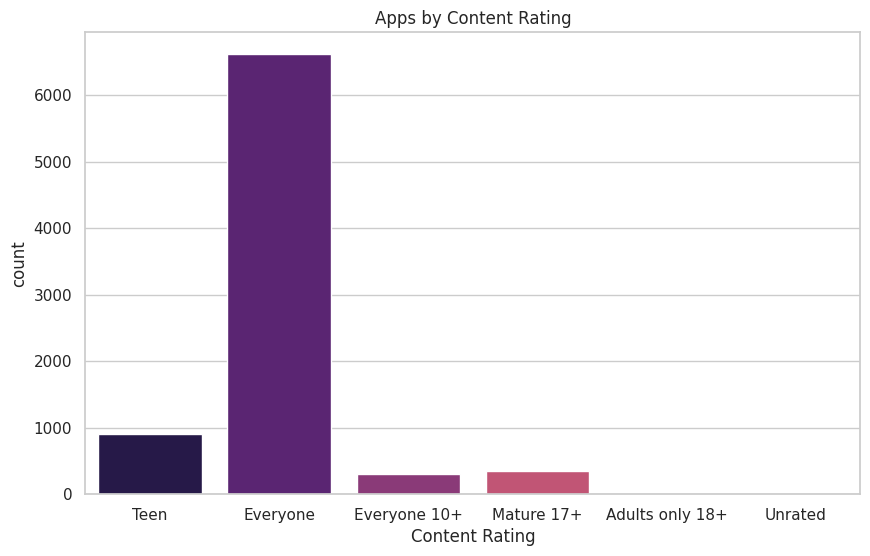

In [40]:
# 7. Distribution of Content Rating
# Shows the target audience for most apps.
plt.figure(figsize=(10, 6))
sns.countplot(x='Content Rating', data=df, hue='Content Rating', palette='magma', legend=False)
plt.title('Apps by Content Rating')
plt.show()

**8. Average Rating by Year of Last Update**

• Explanation: This line chart tracks the average user rating of apps based on the year they were last updated, spanning from 2010 to 2018.

• Analysis: The graph reveals a significant dip in average ratings around 2012, followed by a steady recovery and a sharp increase toward the end of the period (2018).

• Insight: This trend indicates that apps maintained with recent updates tend to have higher user satisfaction. The peak in 2018 suggests that modern apps are better optimized for current Android hardware and user expectations. It proves that app longevity is directly tied to consistent developer updates; older, "abandoned" apps from the 2011–2012 era suffer from lower ratings as they become obsolete or buggy on newer devices.

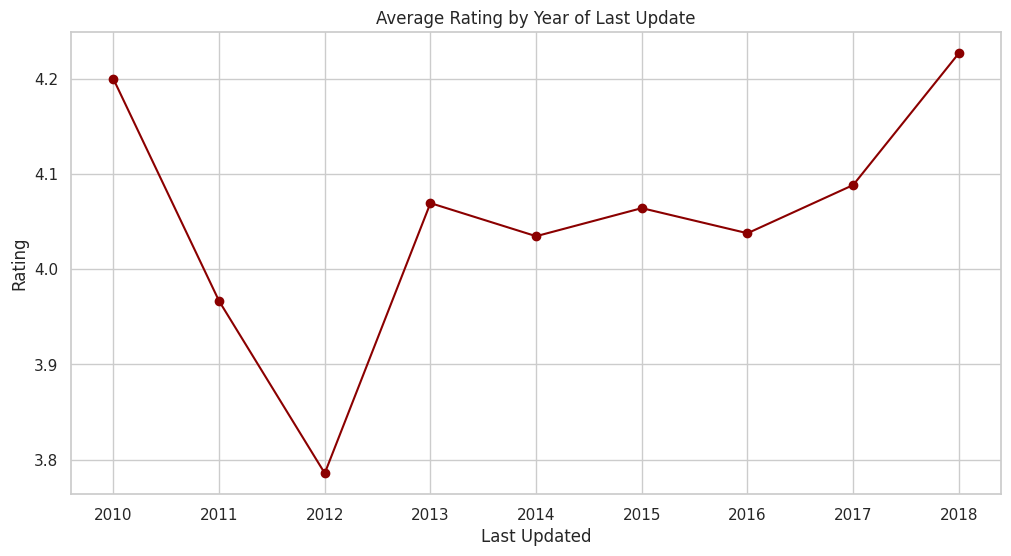

In [38]:
# 8. Average Rating by Year
# Shows trends in app quality over time.
plt.figure(figsize=(12, 6))
df.groupby(df['Last Updated'].dt.year)['Rating'].mean().plot(kind='line', marker='o', color='darkred')
plt.title('Average Rating by Year of Last Update')
plt.ylabel('Rating')
plt.show()

**Visualization & Insights:**

Visualization 1: Distribution of App Ratings

• Why Chosen: To understand the general sentiment of users and see if the ratings follow a normal distribution.

• Main Insight: The data is "left-skewed," meaning most apps have high ratings between 4.0 and 4.7.

• Pattern: Ratings below 3.0 are extremely rare, suggesting that poor-quality apps are either quickly improved or removed from the store.

Visualization 2: Number of Apps per Category

• Why Chosen: To identify which categories are the most crowded and competitive for developers.

• Main Insight: Family, Game, and Tools are the top three categories by volume.

• Pattern: This shows where the most variety exists for users, but also where it is hardest for a new app to stand out.

Visualization 3: Free vs. Paid Apps

• Why Chosen: To compare the two primary business models used on the platform.

• Main Insight: Over 92% of the apps are Free.

• Trend: The "Freemium" model (free download with ads or in-app purchases) is the standard strategy for reaching a mass audience on Android.

Visualization 4: Top 10 Categories by Average Installs

• Why Chosen: To measure the actual "reach" and popularity of different app genres.

• Main Insight: While "Family" has the most apps, Communication and Social categories have the highest average installs.

• Comparison: This highlights that a few massive apps (like WhatsApp or Facebook) drive the majority of traffic in specific categories.

Visualization 5: Rating vs. Content Rating

• Why Chosen: To check if certain age groups (Teens vs. Adults) provide more critical or generous ratings.

• Main Insight: Ratings remain remarkably consistent across all age groups.

• Pattern: There is no significant "bias" based on the target audience; a good app is rated well whether it is for children or adults.

Visualization 6: App Size (MB) vs. Rating

• Why Chosen: To investigate if larger, more complex apps (high MB) result in better user satisfaction.

• Main Insight: There is no strong correlation between file size and rating.

• Pattern: Small, efficient apps can be just as highly rated as large, feature-heavy ones. User experience matters more than file size.

Visualization 7: Distribution of Content Rating

• Why Chosen: To identify the primary target audience for the Google Play Store ecosystem.

• Main Insight: The store is overwhelmingly dominated by apps rated for "Everyone."

• Pattern: Developers prioritize the widest possible demographic to maximize their potential install base.

Visualization 8: Average Rating by Year of Last Update

• Why Chosen: To track how app maintenance and longevity affect user satisfaction.

• Main Insight: Apps updated in 2017 and 2018 show significantly higher average ratings than those last updated in 2011–2012.

• Trend: This proves that regular updates are essential. Apps that aren't maintained become buggy or obsolete on newer Android versions, leading to lower scores.

**Summary of Results (What can be learned?)**

• Maintenance is Key: The strongest predictor of a high rating is a recent update.

• The "Everyone" Market: To reach the most users, developers should aim for a family-friendly content rating.

• Quality over Size: Optimization is more important than adding features that increase the app's MB size.

• Free is Standard: Users expect free content, so developers should focus on alternative monetization (like ads) rather than a high upfront price.